In [1]:
import scipy.integrate as itg
import numpy as np
import matplotlib.pyplot as plt

In [47]:
np.random.seed(5)
v0 = np.random.rand(6)*100 # Initial position & velocities v0 = (x,y,z,vx,vy,vz)
v0

array([22.19931711, 87.07323062, 20.67191553, 91.86109079, 48.84111888,
       61.17438629])

In [48]:
def acc_x(v):
    M1, M2, M3 = 606., 3690., 4615.
    b1, b2 = .3873, .25
    a2, a3 = 5.3178, 12.
    R = np.sqrt(v[0]**2 + v[1]**2 + v[2]**2) # Here v = (x,y,z)
    
    term1 = M1/np.sqrt(R**2 + b1**2)**3
    term2 = M2/np.sqrt(v[0]**2 + v[1]**2 + (a2 + np.sqrt(v[2]**2 + b2**2))**2)**3
    term3 = M3*(R/a3)**(1.02)/(a3*R**2*(1 + (R/a3)**(1.02)))

    d2x_dt2 = -(term1 + term2 + term3)*v[0]
    return d2x_dt2

def acc_y(v):
    M1, M2, M3 = 606., 3690., 4615.
    b1, b2 = .3873, .25
    a2, a3 = 5.3178, 12.
    R = np.sqrt(v[0]**2 + v[1]**2 + v[2]**2)
    
    term1 = M1/np.sqrt(R**2 + b1**2)**3
    term2 = M2/np.sqrt(v[0]**2 + v[1]**2 + (a2 + np.sqrt(v[2]**2 + b2**2))**2)**3
    term3 = M3*(R/a3)**(1.02)/(a3*R**2*(1 + (R/a3)**(1.02)))

    d2y_dt2 = -(term1 + term2 + term3)*v[1]
    return d2y_dt2

def acc_z(v):
    M1, M2, M3 = 606., 3690., 4615.
    b1, b2 = .3873, .25
    a2, a3 = 5.3178, 12.
    R = np.sqrt(v[0]**2 + v[1]**2 + v[2]**2)
    
    term1 = M1/np.sqrt(R**2 + b1**2)**3
    term2 = M2/(np.sqrt(b2**2 + v[2]**2) + np.sqrt(v[0]**2 + v[1]**2 + (a2 + np.sqrt(v[2]**2 + b2**2))**2)**3)
    term3 = M3*(R/a3)**(1.02)/(a3*R**2*(1 + (R/a3)**(1.02)))

    d2x_dt2 = -(term1 + term2 + term3)*v[0]
    return d2x_dt2

def dsystem(t,v):
    vx, vy, vz = v[3], v[4], v[5]
    ax = acc_x(v)
    ay = acc_y(v)
    az = acc_z(v)
    return np.array([vx, vy, vz, ax, ay, az])

In [54]:
t0, tf = 0, 10 # Integration will be from a 0 time unit to 10 galactic time units
#time_ticks = 

solver = RK45(fun = orbit_rhs,
              t0 = 0,
              y0 = y0,
              t_bound = 100000000, 
              max_step = 1000)
ts, states = [solver.t], [solver.y.copy()]

while solver.status == 'running':
    solver.step()               # advances one adaptive RK45 step
    ts.append(solver.t)
    states.append(solver.y.copy())

states = np.array(states)

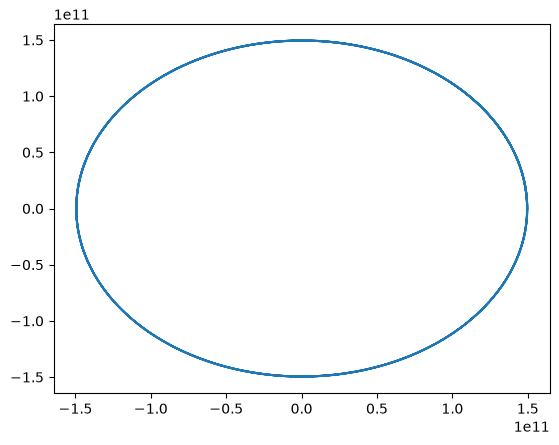

In [55]:
plt.plot(states[:,0], states[:,1])
plt.show()

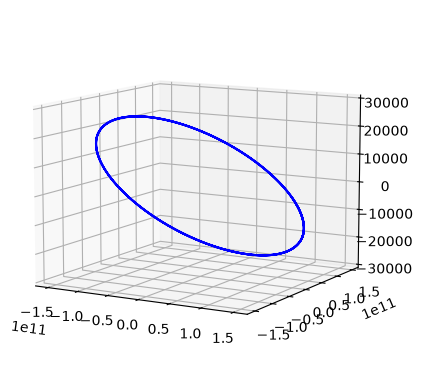

In [56]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
ax.plot(states[:,0], states[:,1], states[:,3], label='Curva 3D', color='b')
ax.view_init(elev=10, roll=0)
plt.show()